## Plan
- Load pickle file - Model Files/patient_risk_model.pkl
- Evaluate on training and test data and generate confusion matrix, precision, recall & F1 Score
- Generate feature importance and explainability summaries
- Segment performance by gender

In [1]:
import pandas as pd
from pycaret.classification import load_model
import json
from sklearn.metrics import confusion_matrix, classification_report
import shap
import matplotlib.pyplot as plt

In [2]:
# Load picke file from Model Files/patient_risk_model.pkl
model_name = "../../Model Files/patient_risk_model"
risk_model = load_model(model_name)

# Read model_table.csv and sort by visit_date
DATA_PATH = "../../Database/model_table.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["visit_date", "registration_date", "billing_date"])
df = df.sort_values("visit_date").reset_index(drop=True)

# Read model feature json file from Model Files/patient_risk_model_feature_schema.json
FEATURES_PATH = "../../Model Files/patient_risk_model_feature_schema.json"
with open(FEATURES_PATH, "r") as f:
    model_features = [feat["name"] for feat in json.load(f)["features"]]

# Create a df only for those features + target
columns_to_keep = model_features + ["risk_score", "visit_date"]
df = df[columns_to_keep]

# Create x and y for the model 80:20 split no shuffling
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]




Transformation Pipeline and Model Successfully Loaded


## Confusion Matrix, Recall & F1

In [3]:
# Confusion matrices and precision, recall, and F1-score for the test set
y_true = test_df["risk_score"]
X_test = test_df.drop(columns=["risk_score", "visit_date"])
y_pred = risk_model.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred))    


Confusion Matrix:
[[412 272 339]
 [931 787 762]
 [561 477 459]]

Classification Report:
              precision    recall  f1-score   support

        High       0.22      0.40      0.28      1023
         Low       0.51      0.32      0.39      2480
      Medium       0.29      0.31      0.30      1497

    accuracy                           0.33      5000
   macro avg       0.34      0.34      0.32      5000
weighted avg       0.39      0.33      0.34      5000



In [4]:
# Showcase feature importance for the risk model
print("\nFeature Importance for the Risk Model:")
importance_df = pd.DataFrame({
    "Feature": model_features,
    "Importance": risk_model.feature_importances_
}).sort_values("Importance", ascending=False)
print(importance_df)   


Feature Importance for the Risk Model:
           Feature  Importance
1           gender    0.341791
2  visit_frequency    0.340335
0     chronic_flag    0.317874


## Model Explanation

Transformation Pipeline and Model Successfully Loaded

--- SHAP Waterfall Plot for Patient 1 ---
Profile: Chronic=1, Gender=M, Visits=12
Prediction: Class Medium (Probabilities: [0.248 0.329 0.423])


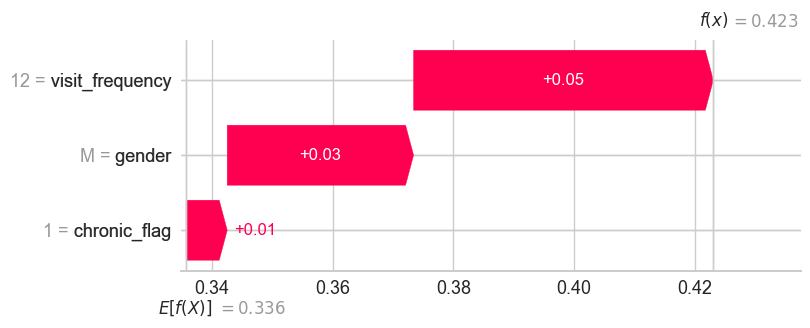


--- SHAP Waterfall Plot for Patient 2 ---
Profile: Chronic=0, Gender=F, Visits=1
Prediction: Class Low (Probabilities: [0.26  0.373 0.367])


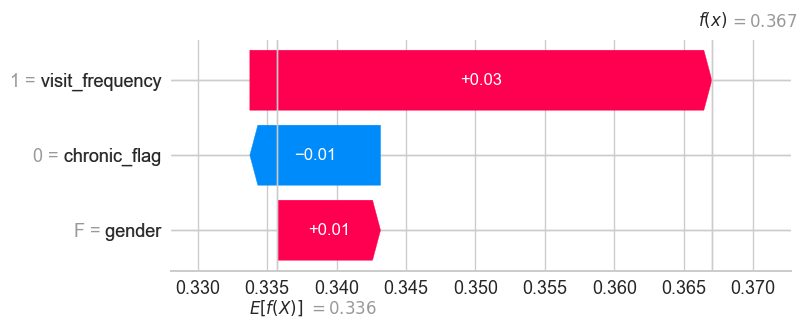


--- SHAP Waterfall Plot for Patient 3 ---
Profile: Chronic=1, Gender=F, Visits=4
Prediction: Class Medium (Probabilities: [0.331 0.311 0.358])


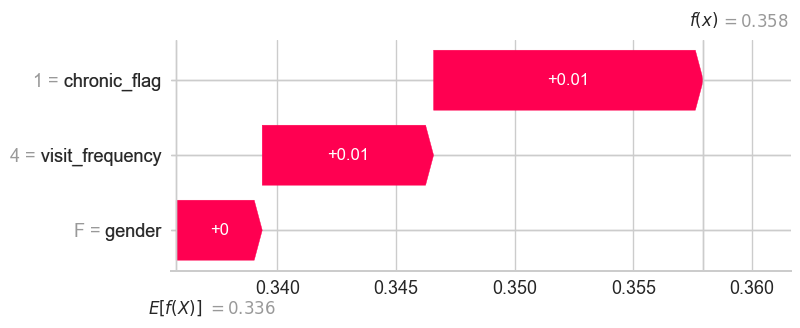


--- SHAP Waterfall Plot for Patient 4 ---
Profile: Chronic=0, Gender=M, Visits=8
Prediction: Class Low (Probabilities: [0.324 0.34  0.336])


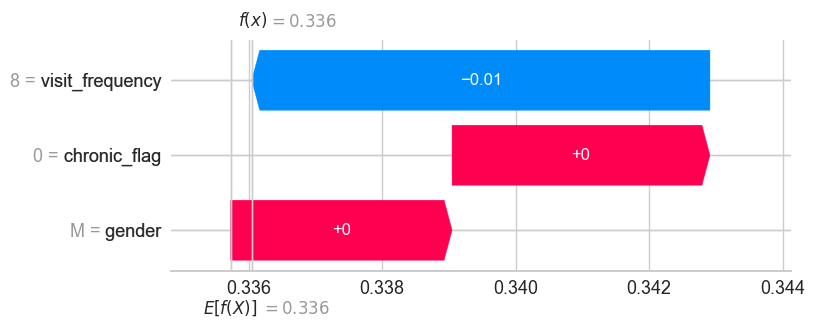


--- SHAP Waterfall Plot for Patient 5 ---
Profile: Chronic=1, Gender=M, Visits=0
Prediction: Class High (Probabilities: [0.395 0.291 0.314])


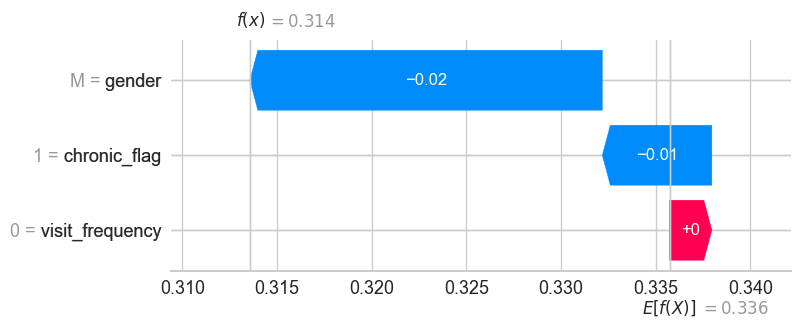

In [5]:
DATA_PATH = "../../Database/model_table.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["visit_date", "registration_date", "billing_date"])

# Sort by visit_date immediately — ensures temporal order for all downstream operations
df = df.sort_values("visit_date").reset_index(drop=True)


lean_columns = ["chronic_flag", "gender", "visit_frequency"]

# df is already sorted by visit_date (done at load time) — no shuffling, no data leakage
data_lean = df[lean_columns]

# Load the pipeline and extract the components
production_model = load_model("../../Model Files/patient_risk_model")
prep_pipeline = production_model[:-1]
raw_xgb = production_model.steps[-1][1]


# This converts "M" and "F" into numbers so SHAP doesn't crash
background_transformed = prep_pipeline.transform(data_lean.sample(100, random_state=42))

# Create the Black-Box Explainer
explainer = shap.Explainer(raw_xgb.predict_proba, background_transformed)


# --- IN PRODUCTION WHEN A PATIENT ARRIVES ---
import matplotlib.pyplot as plt
import numpy as np

# 5 New patients arrive (Raw Data) with different combinations
new_patients_raw = pd.DataFrame([
    {"chronic_flag": 1, "gender": "M", "visit_frequency": 12},  # High risk male
    {"chronic_flag": 0, "gender": "F", "visit_frequency": 1},   # Low risk female
    {"chronic_flag": 1, "gender": "F", "visit_frequency": 4},   # Medium risk female
    {"chronic_flag": 0, "gender": "M", "visit_frequency": 8},   # Medium risk male
    {"chronic_flag": 1, "gender": "M", "visit_frequency": 0}    # New chronic male
])

for i in range(len(new_patients_raw)):
    # Extract a single patient as a DataFrame
    patient_raw = new_patients_raw.iloc[[i]]
    
    # Transform the new patient data
    patient_transformed = prep_pipeline.transform(patient_raw)
    
    # Make prediction using the full pipeline
    pred_class = production_model.predict(patient_raw)[0]
    pred_proba = production_model.predict_proba(patient_raw)[0]
    
    # Generate SHAP values
    shap_values_new = explainer(patient_transformed)
    
    # Replace the transformed numerical data with the original raw labels for display
    shap_values_new.data = patient_raw.values
    
    print(f"\n--- SHAP Waterfall Plot for Patient {i+1} ---")
    print(f"Profile: Chronic={patient_raw['chronic_flag'].values[0]}, Gender={patient_raw['gender'].values[0]}, Visits={patient_raw['visit_frequency'].values[0]}")
    print(f"Prediction: Class {pred_class} (Probabilities: {np.round(pred_proba, 3)})")
    
    # Plot the Waterfall for Class 2 (High Risk)
    shap.plots.waterfall(shap_values_new[0, :, 2], show=False)
    plt.show()

## Model Card

#### Model Details
- Model Name: patient_risk_model
- Model Type: Extreme Gradient Boosting (XGBoost) multi-class classifier.
- Architecture: Tree-based ensemble (gbtree booster), optimized for multi-class soft probabilities (multi:softprob).
- Frameworks: PyCaret (Pipeline & Preprocessing), scikit-learn, XGBoost.
- Date: May 2026
#### Intended Use
- Primary Use Case: To predict the categorical risk tier (e.g., Low, Medium, High) of a patient based on historical visit frequency, biological sex, and the presence of chronic conditions.
- Intended Users: Healthcare administrators, triage nurses, or clinical staff requiring automated risk stratification for patient queue management or resource allocation.
- Out-of-Scope Uses:
    - This model is not a diagnostic tool and should not be used to diagnose specific medical conditions.
    - It should not be the sole decision-maker for denying care, altering treatment plans, or determining insurance premiums.

#### Data Processing
- Input Features:
    - chronic_flag (Binary/Categorical): Indicates the presence of a chronic condition.
    - gender (Categorical): Patient's biological sex (M/F), encoded via Ordinal/One-Hot encoding.
    - visit_frequency (Numeric): Historical count of patient visits.
- Target Variable: risk_score (Multi-class).
- Training Split Strategy: Chronological split without shuffling (data_split_shuffle=False). The model was explicitly trained on past data to predict future, unseen temporal data to prevent data leakage.
- Class Imbalance: Handled natively during training via PyCaret (fix_imbalance=True) to ensure minority risk classes are appropriately weighted.
- Scaling: Continuous variables normalized via PyCaret (normalize=True).
#### Hyper Parameters
The model utilizes a shallow-but-robust tree structure to prevent overfitting on the lean feature set:
  - Max Depth: 8
  - Estimators: 10
  - Learning Rate: 0.15
  - Subsample Ratio: 0.5 
  - Regularization: Alpha = 2, Lambda = 0.005
#### Ethical Considerations & Limitations
  - Gender Bias Risk: Because gender is a direct input feature, the model may explicitly learn different risk thresholds for men vs. women. Depending on the training data, this could reflect genuine biological risk factors, or it could reflect historical systemic biases in how often different genders seek medical care.
  - Feature Sparsity: Relying on only three features makes the model highly interpretable but limits its clinical depth. Two patients with the same gender, chronic flag, and visit count will receive the exact same risk score, regardless of actual symptom severity.
   - Interpretability: The model is an ensemble black-box, necessitating the use of SHAP (SHapley Additive exPlanations) for local explainability to ensure clinical staff can understand individual predictions.